# Metodología de preprocesamiento



1. Tratamiento de valores faltantes que se obtuvieron despues de calcular los atributos con rezago. 
2. Despalzar hacia adelante a las variables con valores negativos. 
3. acampanar los atributos predictores y objetivo con boxcox. 
4. Escalar con probablemente con la téctica de estandarizado. 

1. Visualizar al atributo a preprocesar y preprocesado (uno al lado del otro)
2. Inferir la estrategia de preprocesamiento para cada atributo (Sea meteorológico o epidemiológico). 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

Esta es una propuesta metodológica refinada y técnica para el preprocesamiento de tu dataset, optimizada para modelos de la familia ARMA (específicamente ARIMAX/SARIMAX). Trabajar con 16 rezagos (lags) para múltiples variables meteorológicas exige un rigor especial para evitar el sesgo y la pérdida de información.

---

## Metodología de Preprocesamiento de Datos para Predicción de Dengue

### 1. Tratamiento de Valores Faltantes (Post-Lagging)
Al generar 16 rezagos, las primeras 16 filas de tu dataset contendrán valores `NaN` de forma natural. 
* **Estrategia:** **Recorte de registros iniciales (Trimming).**
* **Justificación:** En series temporales, imputar los primeros rezagos con la media o interpolación introduce ruido artificial en el "arranque" del modelo. Dado que el dengue tiene una fuerte dependencia estacional, es preferible sacrificar 16 semanas de datos históricos para asegurar que el modelo aprenda de relaciones reales.
* **Visualización:** Histogramas de densidad antes y después de eliminar los `NaN`.

### 2. Tratamiento de Valores Negativos y Estacionarización
Identificamos que variables como el **SOI (Southern Oscillation Index)** pueden tener valores negativos.
* **Estrategia:** **Desplazamiento Constante (Positive Shifting).** Si una variable tiene un mínimo de $-2.5$, se le suma $|min| + 1$ a toda la columna.
* **Justificación:** La transformación Box-Cox (paso siguiente) requiere estrictamente valores positivos ($y > 0$). Este desplazamiento es una transformación lineal que no altera la correlación ni la estructura de la serie temporal.

### 3. Transformación de Estabilización de Varianza (Box-Cox)
* **Estrategia:** Aplicar la transformación de Box-Cox definida por:
$$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(y) & \text{si } \lambda = 0 \end{cases}$$
* **Atributos:** Se aplica a `casos_dengue`, `prec`, `hum_esp`, y sus respectivos lags.
* **Justificación:** Los datos epidemiológicos y de precipitación suelen presentar **heterocedasticidad** (varianza no constante). Box-Cox "acampaña" la distribución, acercándola a la normalidad, lo cual es un supuesto deseable para los residuos de modelos SARIMAX.

### 4. Normalización y Estandarización
* **Estrategia:** **Z-Score Standardization** (Media 0, Desviación Estándar 1).
* **Justificación:** Al tener variables en escalas tan distintas (Temp en °C, Casos en unidades, SOI en índices), el optimizador del modelo podría dar peso excesivo a variables con magnitudes grandes. La estandarización asegura que todas las variables exógenas ($X$) compitan en igualdad de condiciones.

---

## Matriz de Inferencia y Estrategia por Atributo

| Grupo de Atributos | Atributos Específicos | Estrategia de Preprocesamiento | Justificación Teórica |
| :--- | :--- | :--- | :--- |
| **Identificadores Temporales** | `año`, `semana_epi` | **Mantener Original / Coseno-Seno.** | Funcionan como índices. No se escalan para no perder la referencia temporal, aunque en SARIMAX la estacionalidad la maneja el parámetro $S$. |
| **Epidemiológico (Objetivo)** | `casos_dengue` | **Box-Cox + Estandarización.** | El conteo de casos suele tener sesgo a la derecha y picos epidémicos; la transformación estabiliza la varianza para el error del modelo. |
| **Climáticos Continuos** | `temp`, `temp_max`, `temp_min`, `sst`, `hum_rel`, `vel_vi` (y lags) | **Estandarización (Z-Score).** | Estas variables suelen ser aproximadamente normales. La estandarización facilita la convergencia de los algoritmos de máxima verosimilitud. |
| **Climáticos de Acumulación/Extremos** | `prec`, `dias_lluvia`, `uv`, `hum_esp` (y lags) | **Desplazamiento (si hay 0) + Box-Cox + Estandarización.** | La lluvia es altamente estocástica y sesgada. Box-Cox reduce el impacto de valores extremos (outliers) que podrían confundir al modelo. |
| **Índices Climáticos Globales** | `soi` (y lags) | **Desplazamiento Constante + Estandarización.** | El SOI indica eventos El Niño/La Niña. Al ser un índice que oscila sobre cero, requiere desplazamiento para permitir transformaciones de potencia. |

---

## Flujo de Visualización Sugerido

Para validar el proceso, se recomienda generar una figura con dos columnas:

1.  **Columna A (Original):** Gráfico de línea de la serie temporal y su respectivo gráfico de densidad (KDE) para observar el sesgo.
2.  **Columna B (Preprocesado):** La misma variable tras Box-Cox y Estandarización. 



> **Nota Crítica para SARIMAX:** Recuerda que al terminar el preprocesamiento, debes realizar la prueba de **Dickey-Fuller Aumentada (ADF)**. Si la serie `casos_dengue` no es estacionaria tras Box-Cox, el modelo SARIMAX requerirá un parámetro de diferenciación ($d > 0$ o $D > 0$).

¿Deseas que profundicemos en el código necesario para automatizar este preprocesamiento sobre los 16 lags de cada variable?

# Manos a la obra a esta metodología de preprocesamiento. 

Esta es una propuesta metodológica refinada y técnica para el preprocesamiento de tu dataset, optimizada para modelos de la familia ARMA (específicamente ARIMAX/SARIMAX). Trabajar con 16 rezagos (lags) para múltiples variables meteorológicas exige un rigor especial para evitar el sesgo y la pérdida de información.

---



# Metodología de Preprocesamiento de Datos para Predicción de Dengue

## 1. Tratamiento de Valores Faltantes (Post-Lagging)
Al generar 16 rezagos, las primeras 16 filas de tu dataset contendrán valores `NaN` de forma natural. 
* **Estrategia:** **Recorte de registros iniciales (Trimming).**
* **Justificación:** En series temporales, imputar los primeros rezagos con la media o interpolación introduce ruido artificial en el "arranque" del modelo. Dado que el dengue tiene una fuerte dependencia estacional, es preferible sacrificar 16 semanas de datos históricos para asegurar que el modelo aprenda de relaciones reales.
* **Visualización:** Histogramas de densidad antes y después de eliminar los `NaN`.



## 2. Tratamiento de Valores Negativos y Estacionarización
Identificamos que variables como el **SOI (Southern Oscillation Index)** pueden tener valores negativos.
* **Estrategia:** **Desplazamiento Constante (Positive Shifting).** Si una variable tiene un mínimo de $-2.5$, se le suma $|min| + 1$ a toda la columna.
* **Justificación:** La transformación Box-Cox (paso siguiente) requiere estrictamente valores positivos ($y > 0$). Este desplazamiento es una transformación lineal que no altera la correlación ni la estructura de la serie temporal.



## 3. Transformación de Estabilización de Varianza (Box-Cox)
* **Estrategia:** Aplicar la transformación de Box-Cox definida por:
$$
y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(y) & \text{si } \lambda = 0 \end{cases}
$$
* **Atributos:** Se aplica a `casos_dengue`, `prec`, `hum_esp`, y sus respectivos lags.
* **Justificación:** Los datos epidemiológicos y de precipitación suelen presentar **heterocedasticidad** (varianza no constante). Box-Cox "acampaña" la distribución, acercándola a la normalidad, lo cual es un supuesto deseable para los residuos de modelos SARIMAX.



## 4. Normalización y Estandarización
* **Estrategia:** **Z-Score Standardization** (Media 0, Desviación Estándar 1).
* **Justificación:** Al tener variables en escalas tan distintas (Temp en °C, Casos en unidades, SOI en índices), el optimizador del modelo podría dar peso excesivo a variables con magnitudes grandes. La estandarización asegura que todas las variables exógenas ($X$) compitan en igualdad de condiciones.

---



## Matriz de Inferencia y Estrategia por Atributo

| Grupo de Atributos | Atributos Específicos | Estrategia de Preprocesamiento | Justificación Teórica |
| :--- | :--- | :--- | :--- |
| **Identificadores Temporales** | `año`, `semana_epi` | **Mantener Original / Coseno-Seno.** | Funcionan como índices. No se escalan para no perder la referencia temporal, aunque en SARIMAX la estacionalidad la maneja el parámetro $S$. |
| **Epidemiológico (Objetivo)** | `casos_dengue` | **Box-Cox + Estandarización.** | El conteo de casos suele tener sesgo a la derecha y picos epidémicos; la transformación estabiliza la varianza para el error del modelo. |
| **Climáticos Continuos** | `temp`, `temp_max`, `temp_min`, `sst`, `hum_rel`, `vel_vi` (y lags) | **Estandarización (Z-Score).** | Estas variables suelen ser aproximadamente normales. La estandarización facilita la convergencia de los algoritmos de máxima verosimilitud. |
| **Climáticos de Acumulación/Extremos** | `prec`, `dias_lluvia`, `uv`, `hum_esp` (y lags) | **Desplazamiento (si hay 0) + Box-Cox + Estandarización.** | La lluvia es altamente estocástica y sesgada. Box-Cox reduce el impacto de valores extremos (outliers) que podrían confundir al modelo. |
| **Índices Climáticos Globales** | `soi` (y lags) | **Desplazamiento Constante + Estandarización.** | El SOI indica eventos El Niño/La Niña. Al ser un índice que oscila sobre cero, requiere desplazamiento para permitir transformaciones de potencia. |

---



## Flujo de Visualización Sugerido

Para validar el proceso, se recomienda generar una figura con dos columnas:

1.  **Columna A (Original):** Gráfico de línea de la serie temporal y su respectivo gráfico de densidad (KDE) para observar el sesgo.
2.  **Columna B (Preprocesado):** La misma variable tras Box-Cox y Estandarización. 





> **Nota Crítica para SARIMAX:** Recuerda que al terminar el preprocesamiento, debes realizar la prueba de **Dickey-Fuller Aumentada (ADF)**. Si la serie `casos_dengue` no es estacionaria tras Box-Cox, el modelo SARIMAX requerirá un parámetro de diferenciación ($d > 0$ o $D > 0$).

¿Deseas que profundicemos en el código necesario para automatizar este preprocesamiento sobre los 16 lags de cada variable?

Dado que manejar manualmente más de 200 columnas (originales + 16 rezagos por cada una) es propenso a errores, utilizaremos un enfoque de **programación funcional** en Python (Pandas/Scikit-Learn). 



Esta automatización asegura que el tratamiento aplicado a `temp` sea idéntico al de sus 16 `temp_lag_n`, manteniendo la coherencia estadística.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import signal

In [2]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados"
ubicacion_datos_consolidados_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada"
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos\05_ Preprocesamiento"
ubicacion_imagenes_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\5_imagenes"

In [4]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\datos_semanal_meteo_epi_rezagos.xlsx"
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_semanal_meteo_epi_rezagos.xlsx"
df_semanal_meteo_epi_rezago = pd.read_excel(path_janis)
# hacer que fecha sea el indice y sea de tipo datetime
df_semanal_meteo_epi_rezago['fecha'] = pd.to_datetime(df_semanal_meteo_epi_rezago['fecha']) # convertir en tipo datetime
df_semanal_meteo_epi_rezago.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
df_semanal_meteo_epi_rezago.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,sst_lag_7,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12,sst_lag_13,sst_lag_14,sst_lag_15,sst_lag_16
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Código de Automatización de Preprocesamiento


In [5]:

def preprocess_dengue_data(df, skew_threshold=0.5):
    """
    Preprocesamiento avanzado: Tratamiento de nulos, eliminación de negativos,
    detección automática de sesgo y transformación Box-Cox selectiva.
    """
    df_proc = df_semanal_meteo_epi_rezago.copy()
    
    # 1. Tratamiento de Faltantes (Post-Lagging)
    df_proc = df_proc.dropna().reset_index(drop=True)
    
    # 2. Manejo de valores negativos y ceros (Requisito para Box-Cox)
    # Box-Cox requiere datos estrictamente positivos (> 0)
    for col in df_proc.columns:
        if col not in ['año', 'semana_epi']:
            min_val = df_proc[col].min()
            if min_val <= 0:
                # Desplazamos para que el mínimo sea 1
                shift = abs(min_val) + 1
                df_proc[col] = df_proc[col] + shift

    # 3. Identificación de Sesgo y Aplicación de Box-Cox
    lambdas = {}
    cols_transformed = []
    
    # Solo evaluamos variables numéricas que no sean índices temporales
    potential_cols = [c for c in df_proc.columns if c not in ['año', 'semana_epi']]
    
    for col in potential_cols:
        skewness = df_proc[col].skew()
        
        # Si el valor absoluto del sesgo supera el umbral, aplicamos Box-Cox
        if abs(skewness) > skew_threshold:
            df_proc[col], lmbda = stats.boxcox(df_proc[col])
            lambdas[col] = lmbda
            cols_transformed.append(col)
    
    print(f"Variables transformadas por sesgo (>|{skew_threshold}|): {len(cols_transformed)}")
    
    # 4. Estandarización (Z-Score)
    cols_to_scale = [c for c in df_proc.columns if c not in ['año', 'semana_epi']]
    scaler = StandardScaler()
    df_proc[cols_to_scale] = scaler.fit_transform(df_proc[cols_to_scale])
    
    return df_proc, scaler, lambdas

In [7]:

# Ejecución
df_semanal_meteo_epi_rezago_prepo, fitted_scaler, fitted_lambdas = preprocess_dengue_data(df_semanal_meteo_epi_rezago)


Variables transformadas por sesgo (>|0.5|): 135


In [8]:
# Guardar el DataFrame preprocesado
df_semanal_meteo_epi_rezago_prepo.to_excel(f"{ubicacion_datos_consolidados_janis}/datos_semanal_meteo_epi_rezago_preprocesado.xlsx", index=True)

In [9]:
df_semanal_meteo_epi_rezago_prepo.describe().round(2)  

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,sst_lag_7,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12,sst_lag_13,sst_lag_14,sst_lag_15,sst_lag_16
count,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00,...,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00,245.00
mean,2023.14,27.78,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,...,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.37,14.79,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,2021.00,1.00,-2.20,-2.20,-3.02,-2.09,-1.78,-1.99,-1.80,-2.15,...,-1.93,-1.92,-2.03,-2.02,-2.01,-2.00,-1.99,-1.98,-1.95,-1.93
25%,2022.00,16.00,-0.79,-0.81,-0.65,-0.82,-0.95,-0.69,-0.77,-0.77,...,-0.88,-0.89,-0.90,-0.89,-0.89,-0.89,-0.88,-0.87,-0.88,-0.88
50%,2023.00,28.00,-0.04,-0.18,-0.00,0.08,0.50,0.10,0.14,-0.04,...,0.01,0.01,0.01,0.02,0.02,0.03,0.03,0.04,0.04,0.05
75%,2024.00,40.00,0.67,0.88,0.58,0.78,0.81,0.65,0.63,0.75,...,0.63,0.63,0.63,0.63,0.63,0.64,0.64,0.64,0.64,0.64
max,2025.00,53.00,2.16,1.87,3.90,2.10,1.42,2.64,1.15,2.53,...,1.89,1.88,1.89,1.88,1.88,1.88,1.87,1.87,1.87,1.87


## Visualización de Diagnóstico (Antes vs. Después)

Para cumplir con tu requerimiento de visualizar "uno al lado del otro", esta función generará gráficos comparativos para cualquier atributo, permitiéndote verificar visualmente la **normalización** y la **estabilización de la varianza**.


In [10]:
df_semanal_meteo_epi_rezago.columns[:10]

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi'],
      dtype='object')

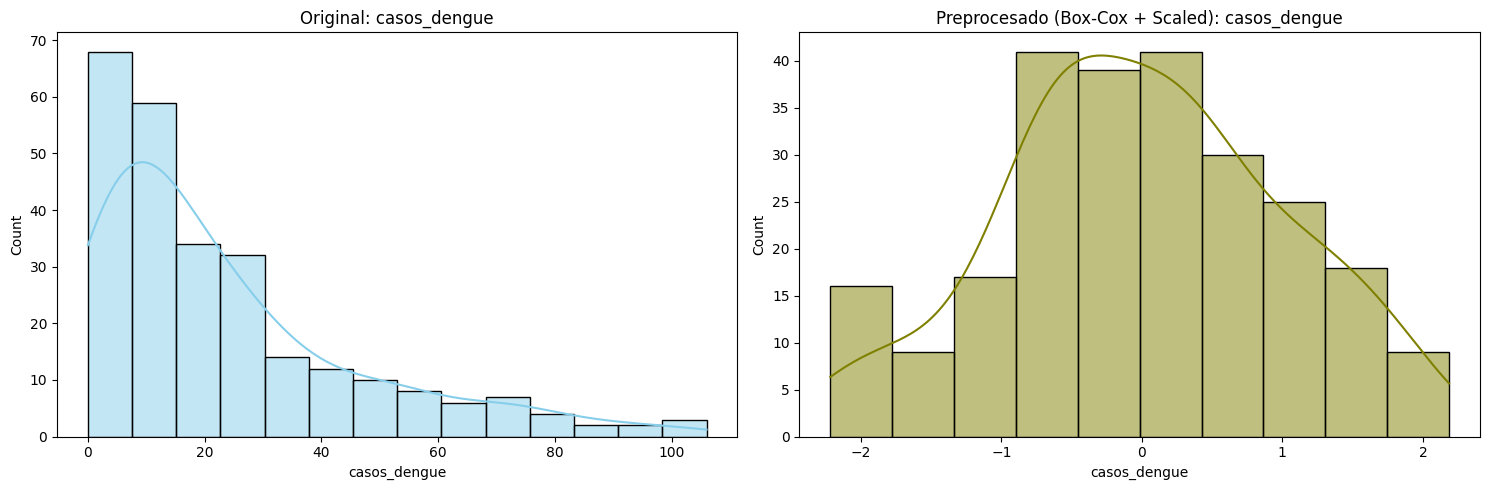

In [15]:
def plot_comparison(df_orig, df_proc, attribute):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Original
    sns.histplot(df_orig[attribute], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Original: {attribute}')
    
    # Preprocesado
    sns.histplot(df_proc[attribute], kde=True, ax=axes[1], color='olive')
    axes[1].set_title(f'Preprocesado (Box-Cox + Scaled): {attribute}')
    
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_comparison(df_semanal_meteo_epi_rezago, \
    df_semanal_meteo_epi_rezago_prepo, \
    'casos_dengue')


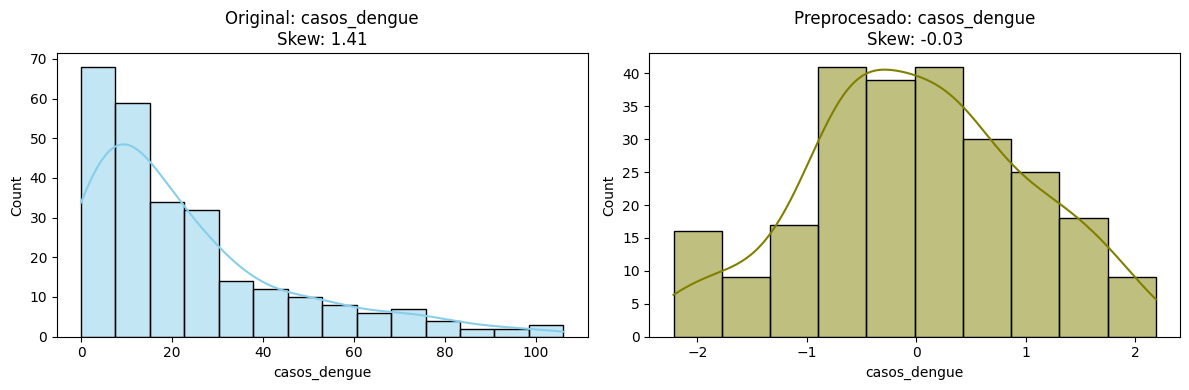

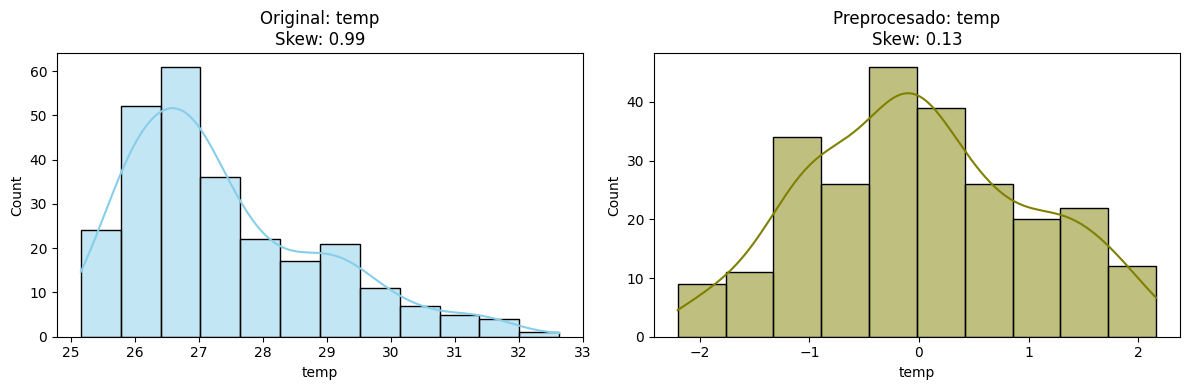

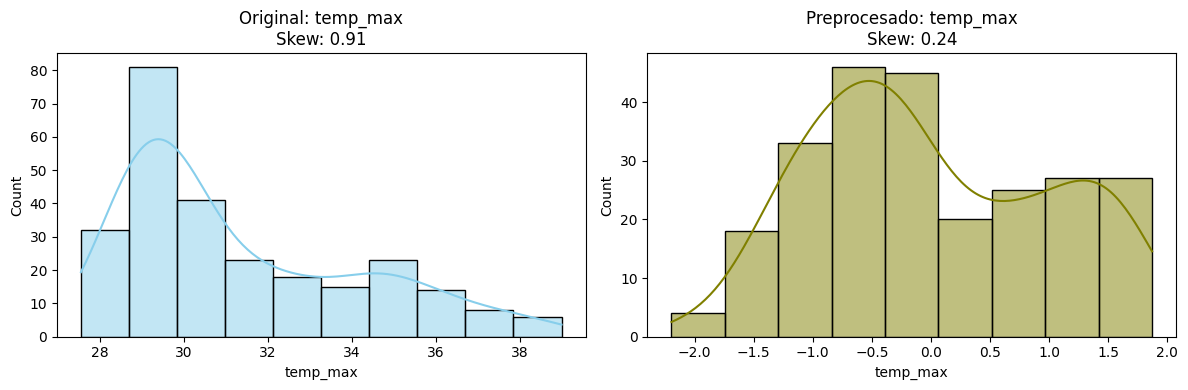

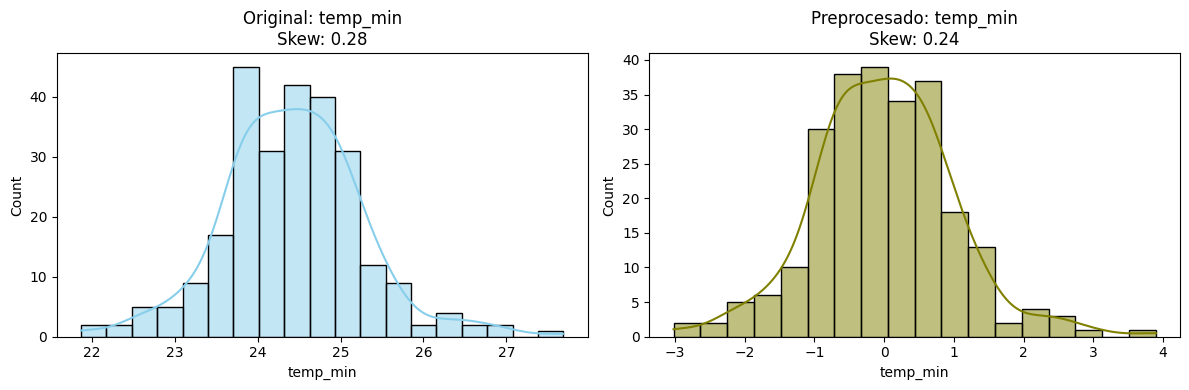

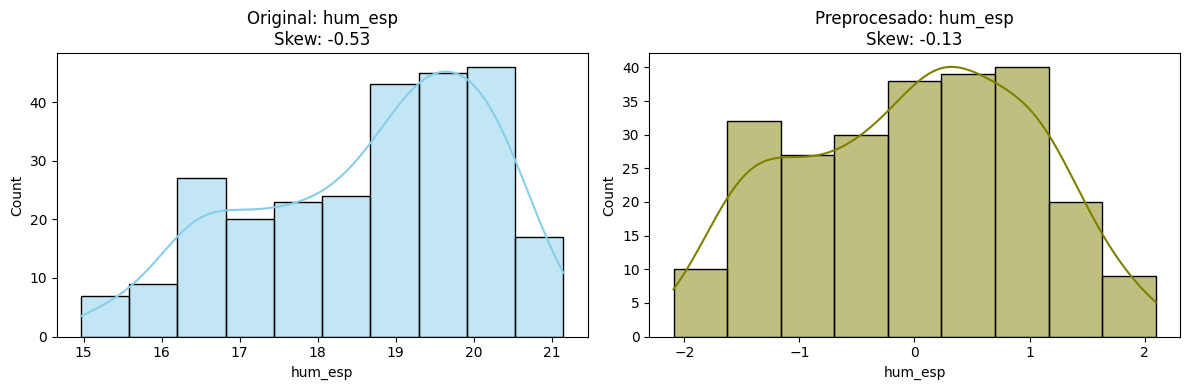

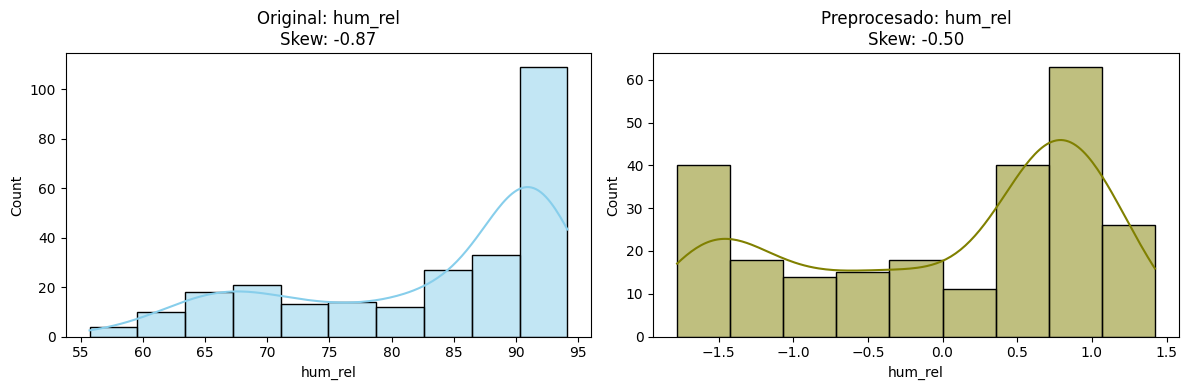

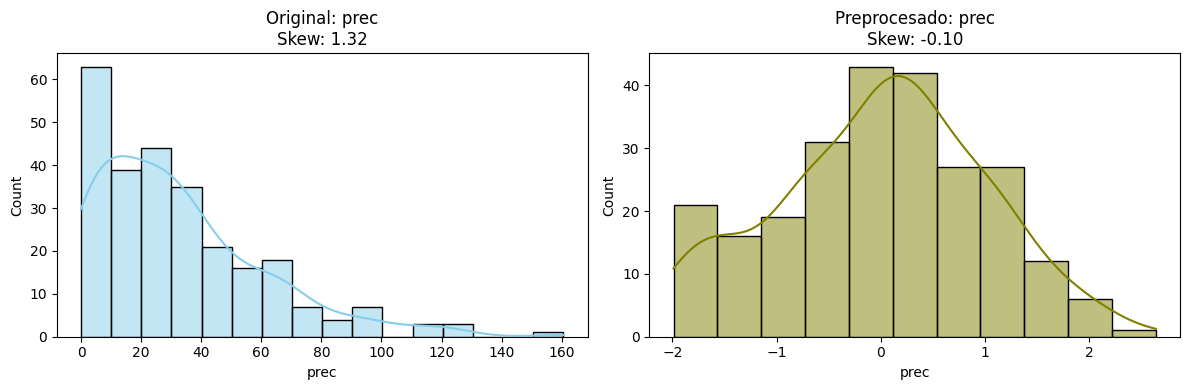

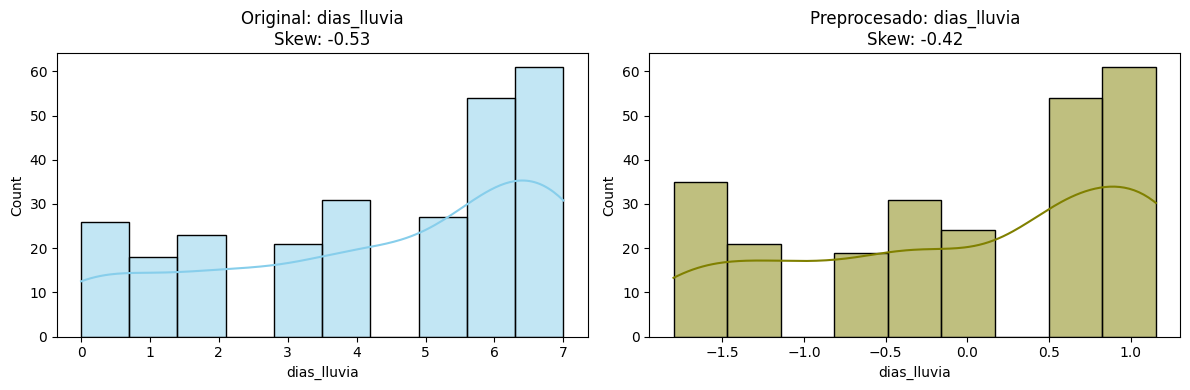

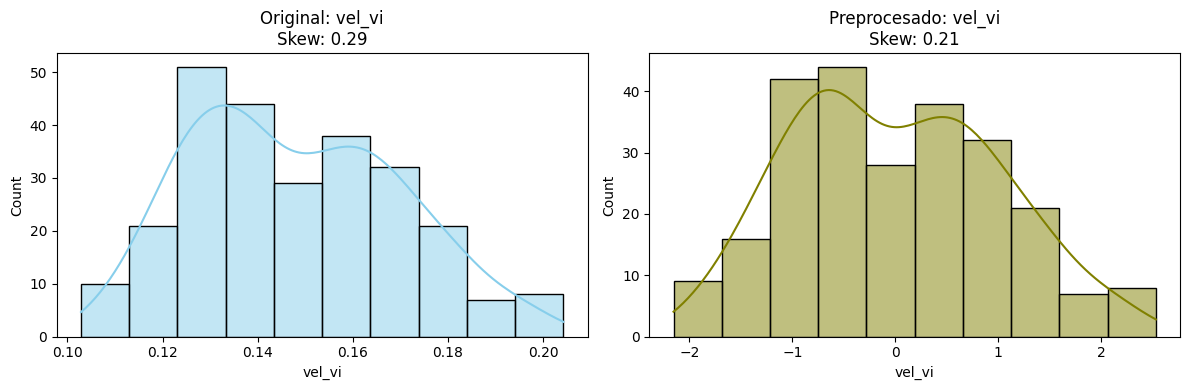

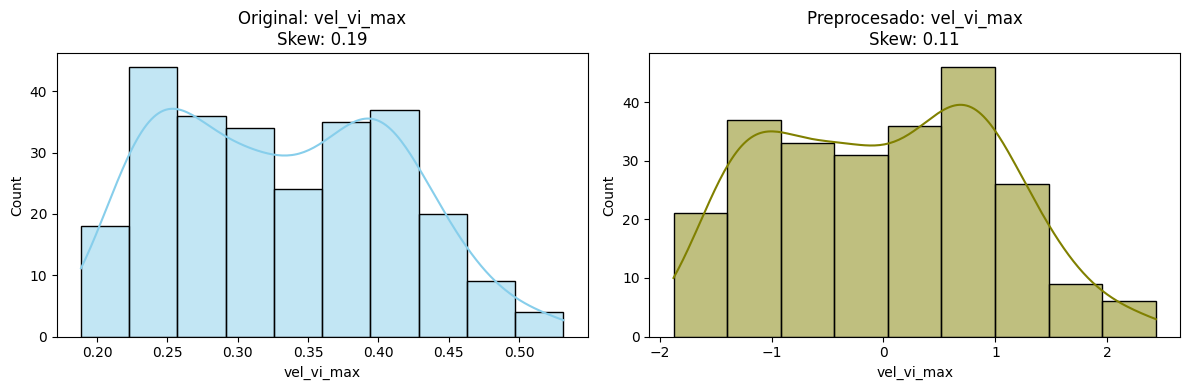

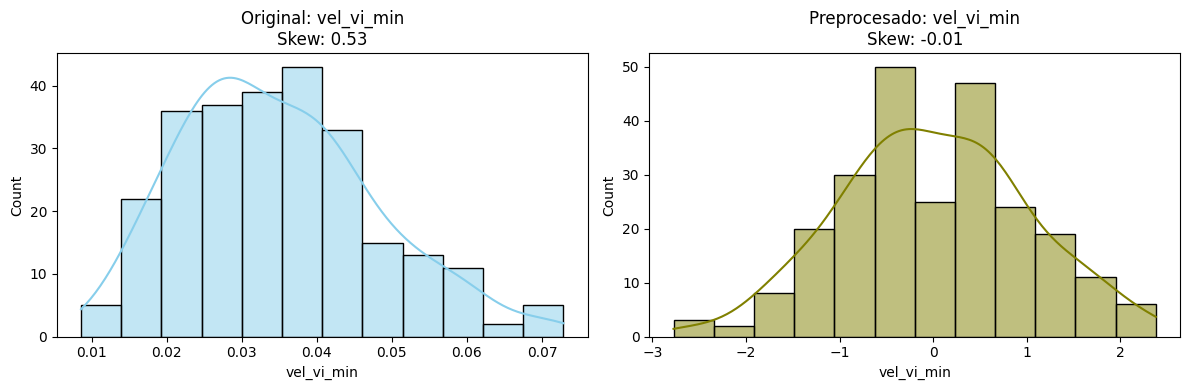

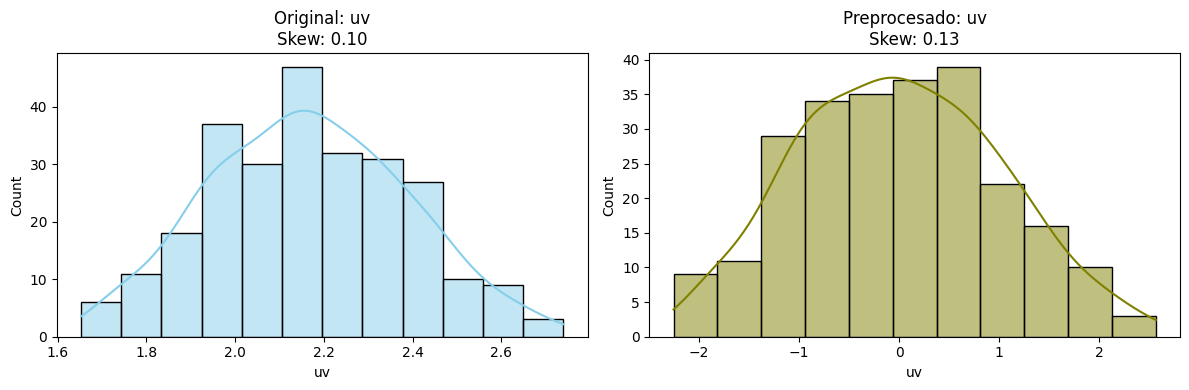

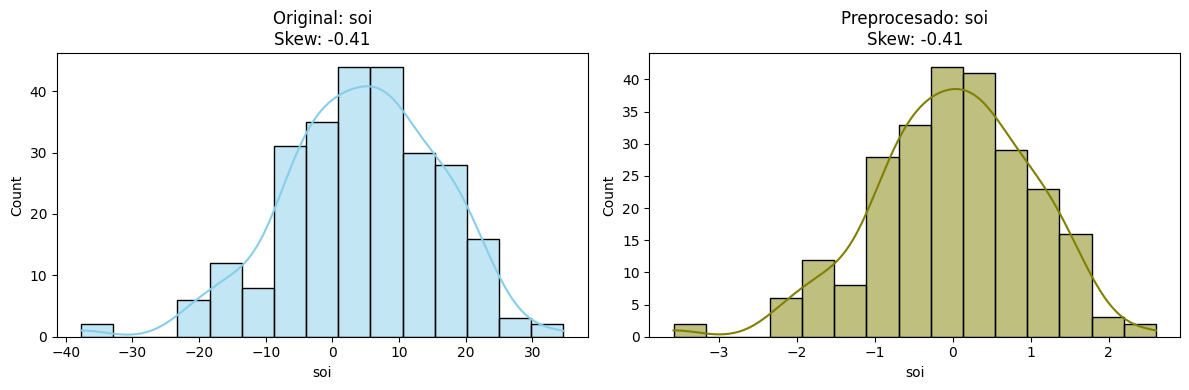

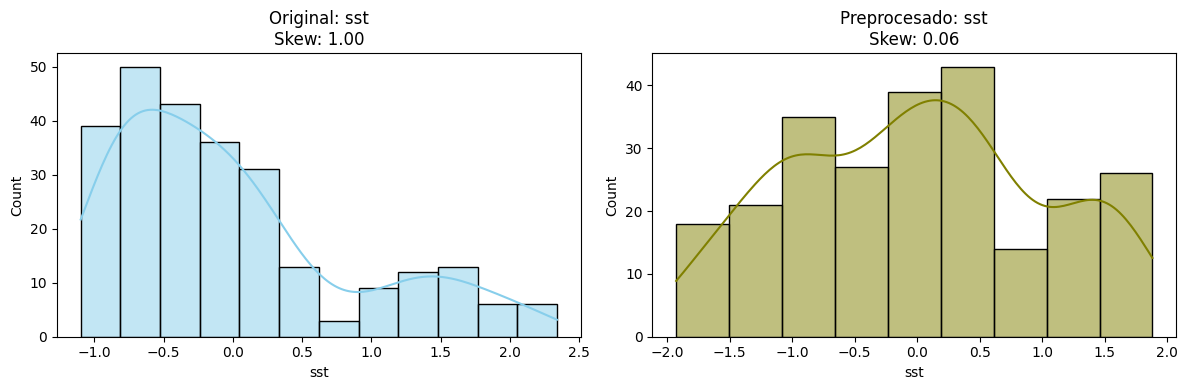

In [12]:
# Lista de variables base (sin rezagos) según tu dataset
variables_base = [
    'casos_dengue', 'temp', 'temp_max', 'temp_min', 
    'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 
    'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv', 'soi', 'sst'
]

def visualizar_matriz_preprocesamiento(df_orig, df_proc, lista_atributos):
    """
    Genera una cuadrícula de comparaciones para una lista de atributos.
    """
    for atributo in lista_atributos:
        if atributo in df_orig.columns and atributo in df_proc.columns:
            # Reutilizamos tu lógica de plot_comparison
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            # Gráfico Original (Izquierda)
            sns.histplot(df_orig[atributo], kde=True, ax=axes[0], color='skyblue')
            axes[0].set_title(f'Original: {atributo}\nSkew: {df_orig[atributo].skew():.2f}')
            
            # Gráfico Preprocesado (Derecha)
            sns.histplot(df_proc[atributo], kde=True, ax=axes[1], color='olive')
            axes[1].set_title(f'Preprocesado: {atributo}\nSkew: {df_proc[atributo].skew():.2f}')
            #guardar cada gráfico individualmente
            plt.savefig(f"{ubicacion_imagenes_janis}/1.histograma_{atributo}.png")

            plt.tight_layout()
            plt.show()
        else:
            print(f"Advertencia: {atributo} no encontrado en uno de los DataFrames.")

# Ejecución de la matriz
visualizar_matriz_preprocesamiento(
    df_semanal_meteo_epi_rezago, 
    df_semanal_meteo_epi_rezago_prepo, 
    variables_base
)

## Justificación Técnica de la Estrategia

### ¿Por qué Box-Cox antes que Estandarizar?
Si estandarizas primero, tendrás valores negativos (centrados en 0), lo que imposibilita matemáticamente aplicar Box-Cox. La secuencia lógica debe ser: **Positivización $\rightarrow$ Box-Cox $\rightarrow$ Estandarización.**



### ¿Por qué tratar los rezagos igual que la original?
En modelos SARIMAX, el coeficiente de un rezago (ej. `temp_lag_4`) debe ser comparable con el coeficiente de la variable actual (`temp`). Si escalas la variable original pero no sus rezagos, el modelo asignará "pesos" (Betas) distorsionados, dificultando la interpretación de qué semana climática influye más en el brote de dengue.



### Manejo de la variable Objetivo (`casos_dengue`)
Es vital guardar el valor de `lambda` y los parámetros del `StandardScaler` para la variable objetivo. Cuando el modelo SARIMAX te entregue una predicción, estará en "unidades estandarizadas y transformadas". Deberás aplicar la operación inversa para obtener el número real de casos:
1. **Inversa de Z-Score:** $y_{real} = (y_{pred} \cdot std) + mean$.
2. **Inversa de Box-Cox:** Dependiendo del $\lambda$ obtenido.


In [18]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_semanal_meteo_epi_rezago_prepo.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad.head(13)

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.984030,7.540327e-03,False
temp_max,0.956150,8.845464e-07,False
temp_min,0.982967,4.935323e-03,False
hum_esp,0.974907,2.499984e-04,False
hum_rel,0.874668,2.615863e-13,False
prec,0.985097,1.160881e-02,False
dias_lluvia,0.885155,1.141346e-12,False
vel_vi,0.983336,5.713949e-03,False
vel_vi_max,0.970826,6.379479e-05,False
vel_vi_min,0.994850,5.792072e-01,True



Calculando correlaciones cruzadas y guardando gráficos...



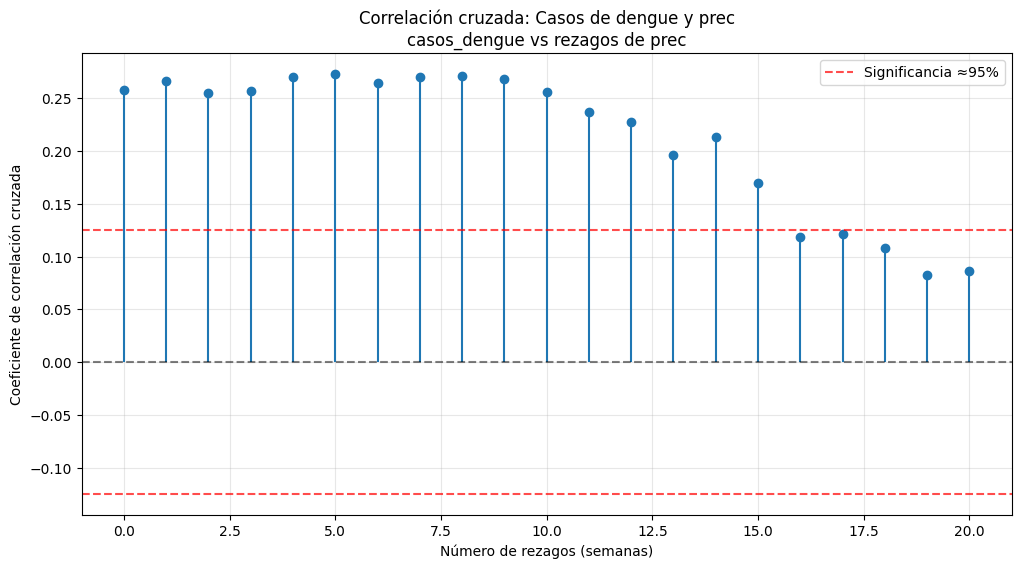


=== Rezagos más relevantes para casos_dengue vs prec ===
Lag  1: +0.2665
Lag  2: +0.2553
Lag  3: +0.2574
Lag  4: +0.2701
Lag  5: +0.2730
Lag  6: +0.2646
Lag  7: +0.2705
Lag  8: +0.2713
Lag  9: +0.2682
Lag 10: +0.2563
Lag 11: +0.2367
Lag 12: +0.2278
Lag 13: +0.1962
Lag 14: +0.2135
Lag 15: +0.1697
------------------------------------------------------------


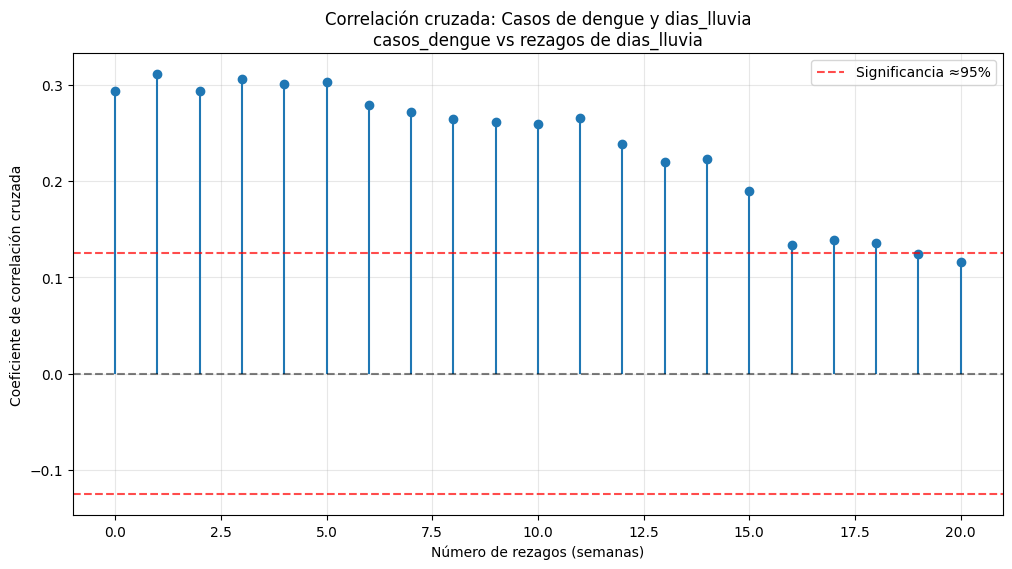


=== Rezagos más relevantes para casos_dengue vs dias_lluvia ===
Lag  1: +0.3111
Lag  2: +0.2938
Lag  3: +0.3066
Lag  4: +0.3012
Lag  5: +0.3034
Lag  6: +0.2791
Lag  7: +0.2719
Lag  8: +0.2650
Lag  9: +0.2612
Lag 10: +0.2589
Lag 11: +0.2659
Lag 12: +0.2390
Lag 13: +0.2197
Lag 14: +0.2230
Lag 15: +0.1898
------------------------------------------------------------


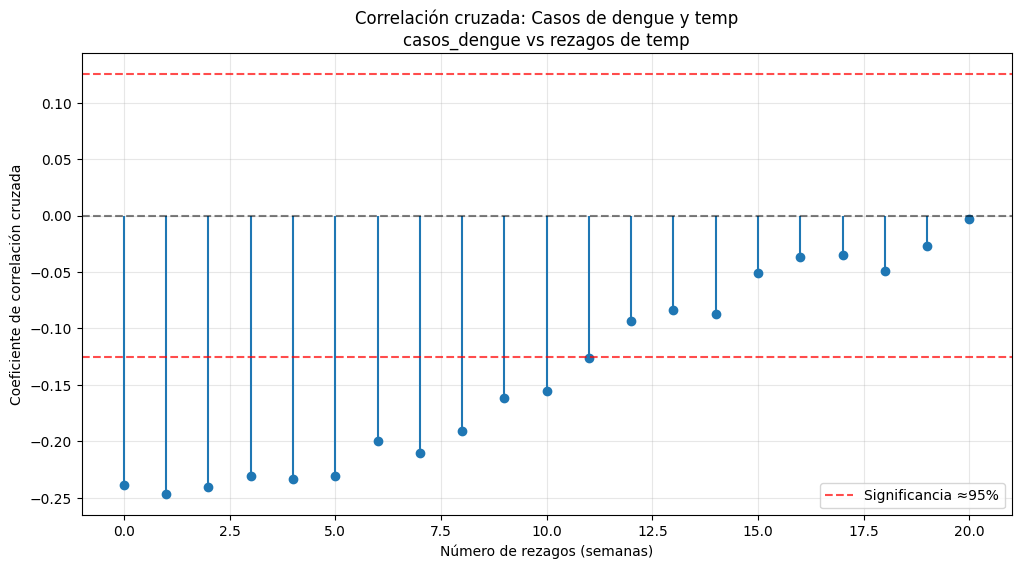


=== Rezagos más relevantes para casos_dengue vs temp ===
Lag  1: -0.2468
Lag  2: -0.2407
Lag  3: -0.2308
Lag  4: -0.2337
Lag  5: -0.2306
Lag  6: -0.2000
Lag  7: -0.2103
Lag  8: -0.1909
Lag  9: -0.1620
Lag 10: -0.1550
------------------------------------------------------------


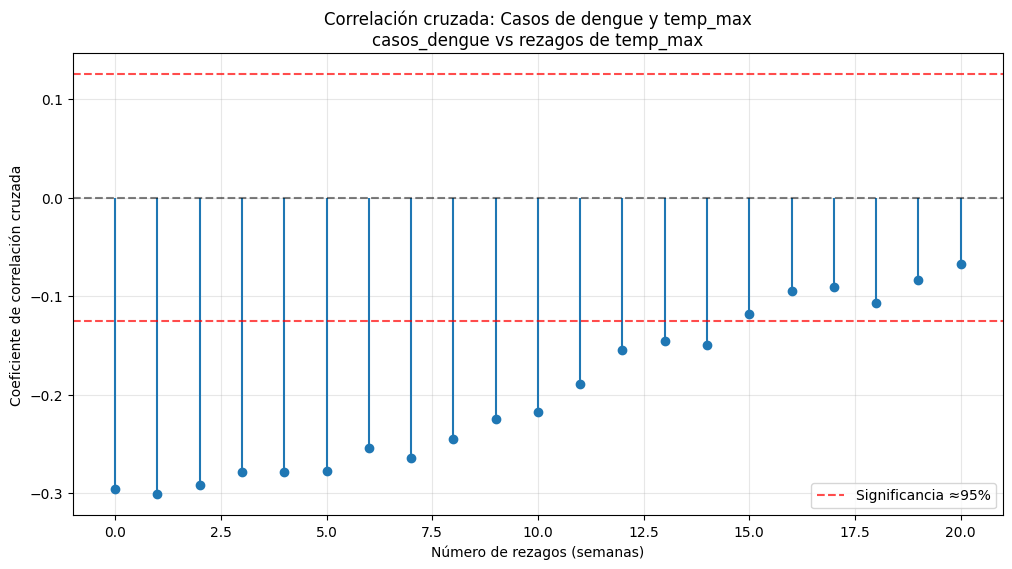


=== Rezagos más relevantes para casos_dengue vs temp_max ===
Lag  1: -0.3010
Lag  2: -0.2918
Lag  3: -0.2787
Lag  4: -0.2783
Lag  5: -0.2774
Lag  6: -0.2543
Lag  7: -0.2639
Lag  8: -0.2451
Lag  9: -0.2242
Lag 10: -0.2172
Lag 11: -0.1894
Lag 12: -0.1541
------------------------------------------------------------


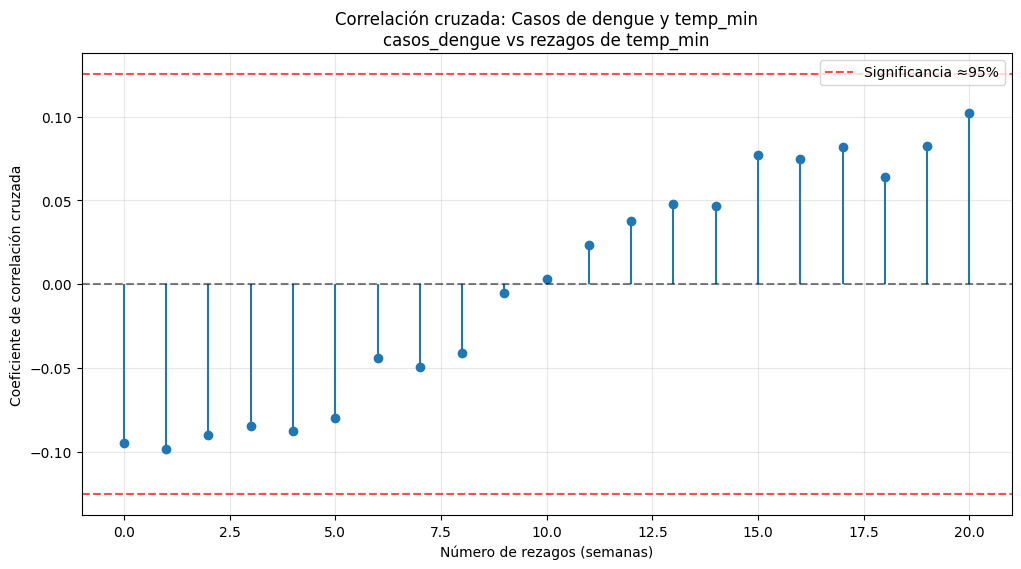


=== Rezagos más relevantes para casos_dengue vs temp_min ===
------------------------------------------------------------


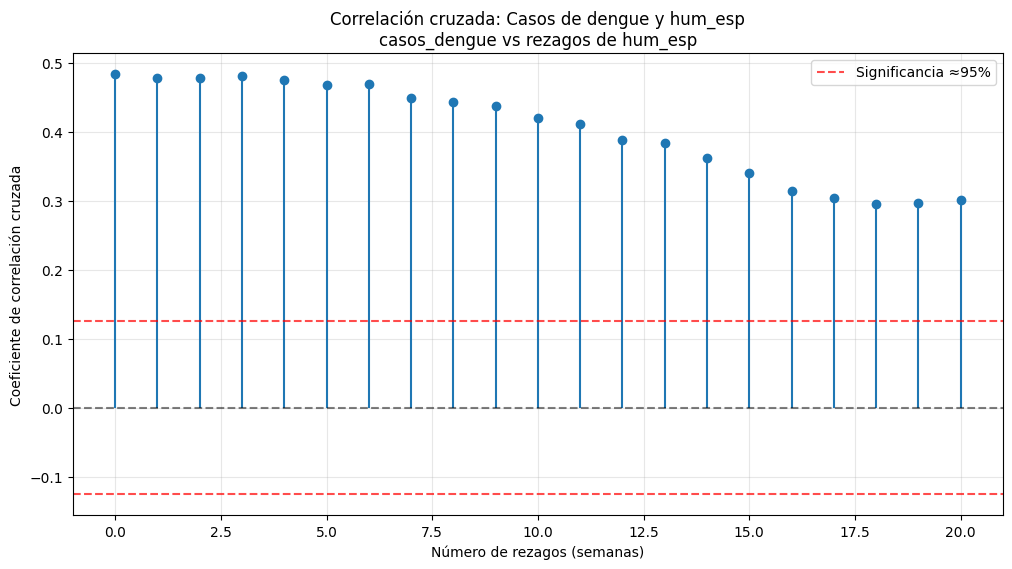


=== Rezagos más relevantes para casos_dengue vs hum_esp ===
Lag  1: +0.4775
Lag  2: +0.4776
Lag  3: +0.4813
Lag  4: +0.4742
Lag  5: +0.4681
Lag  6: +0.4683
Lag  7: +0.4487
Lag  8: +0.4428
Lag  9: +0.4378
Lag 10: +0.4198
Lag 11: +0.4114
Lag 12: +0.3883
Lag 13: +0.3839
Lag 14: +0.3617
Lag 15: +0.3407
Lag 16: +0.3145
Lag 17: +0.3041
Lag 18: +0.2945
Lag 19: +0.2962
Lag 20: +0.3014
------------------------------------------------------------


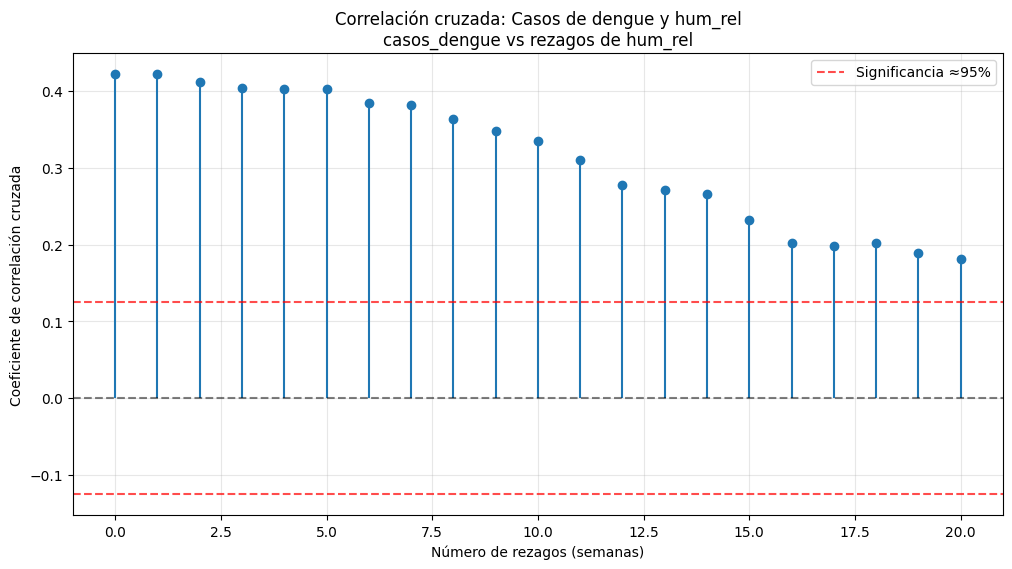


=== Rezagos más relevantes para casos_dengue vs hum_rel ===
Lag  1: +0.4219
Lag  2: +0.4121
Lag  3: +0.4047
Lag  4: +0.4032
Lag  5: +0.4030
Lag  6: +0.3845
Lag  7: +0.3819
Lag  8: +0.3645
Lag  9: +0.3483
Lag 10: +0.3346
Lag 11: +0.3109
Lag 12: +0.2784
Lag 13: +0.2717
Lag 14: +0.2664
Lag 15: +0.2322
Lag 16: +0.2029
Lag 17: +0.1978
Lag 18: +0.2017
Lag 19: +0.1899
Lag 20: +0.1810
------------------------------------------------------------


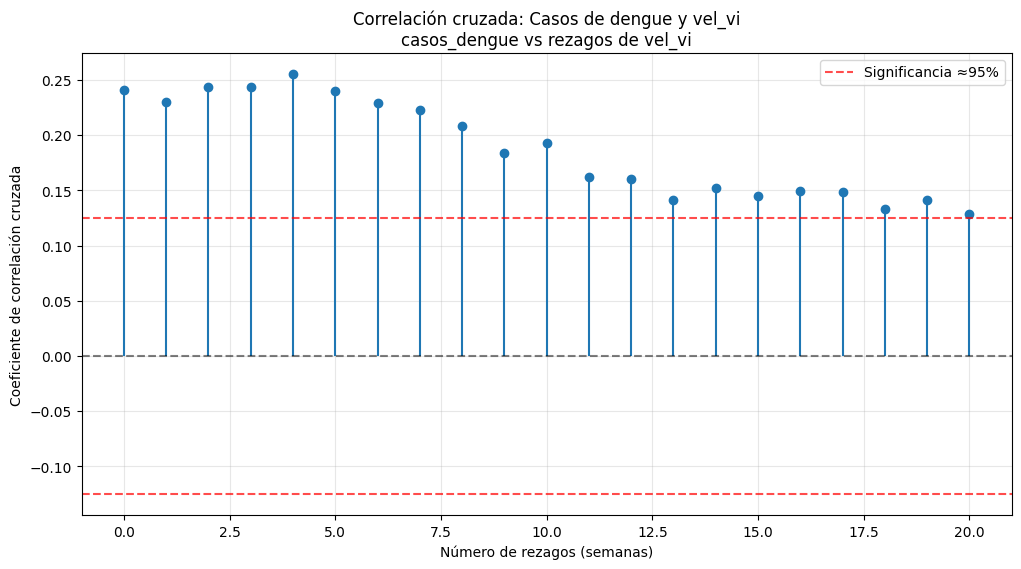


=== Rezagos más relevantes para casos_dengue vs vel_vi ===
Lag  1: +0.2302
Lag  2: +0.2433
Lag  3: +0.2434
Lag  4: +0.2552
Lag  5: +0.2398
Lag  6: +0.2288
Lag  7: +0.2232
Lag  8: +0.2080
Lag  9: +0.1835
Lag 10: +0.1933
Lag 11: +0.1618
Lag 12: +0.1603
Lag 14: +0.1521
------------------------------------------------------------


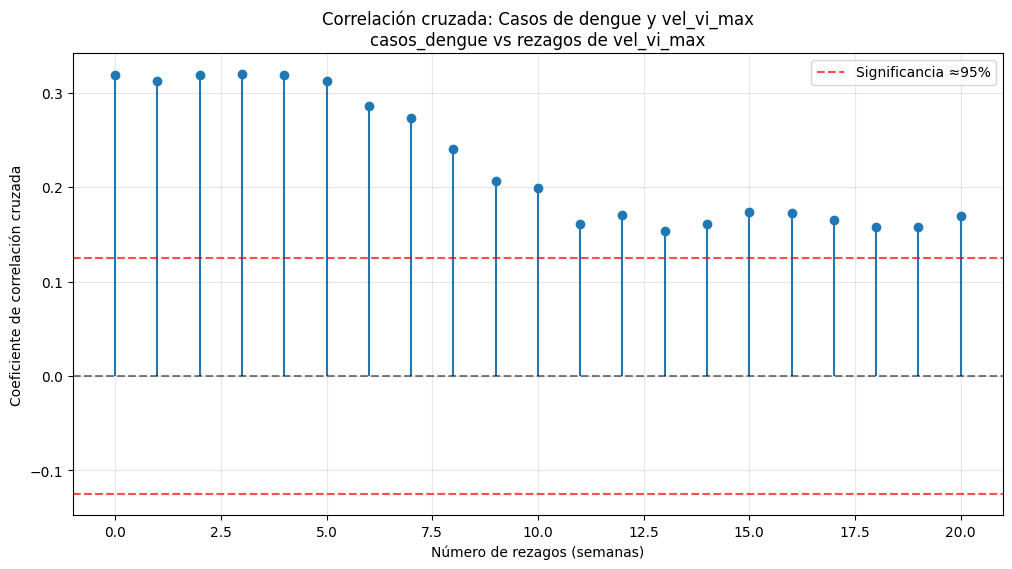


=== Rezagos más relevantes para casos_dengue vs vel_vi_max ===
Lag  1: +0.3128
Lag  2: +0.3193
Lag  3: +0.3197
Lag  4: +0.3184
Lag  5: +0.3122
Lag  6: +0.2858
Lag  7: +0.2734
Lag  8: +0.2402
Lag  9: +0.2065
Lag 10: +0.1992
Lag 11: +0.1607
Lag 12: +0.1710
Lag 13: +0.1536
Lag 14: +0.1609
Lag 15: +0.1738
Lag 16: +0.1721
Lag 17: +0.1656
Lag 18: +0.1576
Lag 19: +0.1581
Lag 20: +0.1690
------------------------------------------------------------


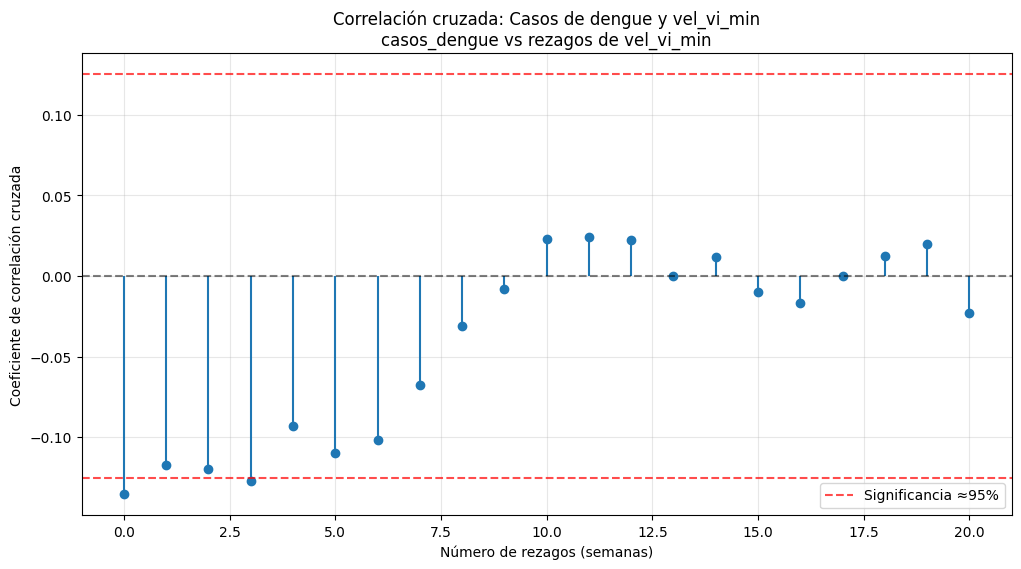


=== Rezagos más relevantes para casos_dengue vs vel_vi_min ===
------------------------------------------------------------


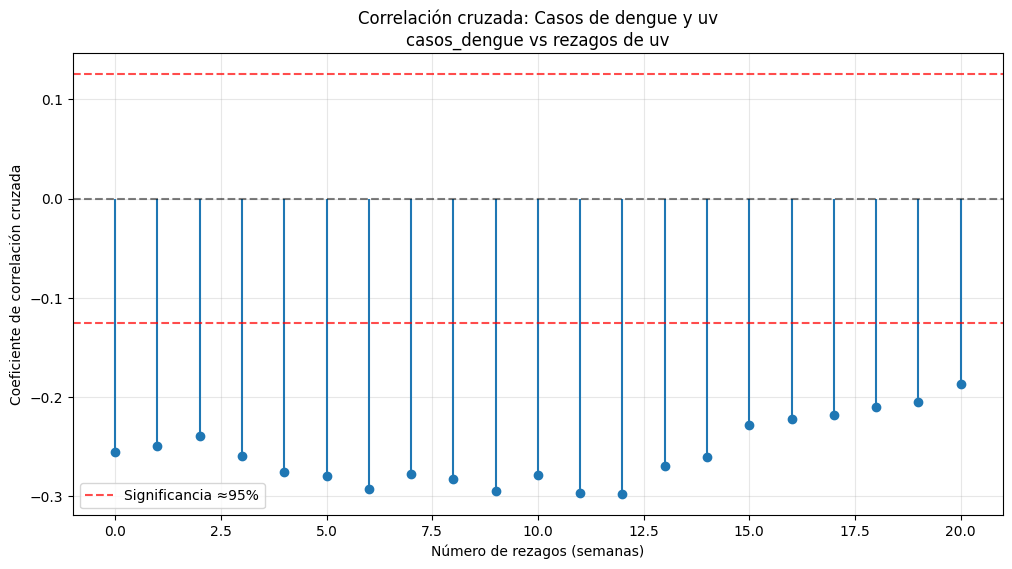


=== Rezagos más relevantes para casos_dengue vs uv ===
Lag  1: -0.2489
Lag  2: -0.2389
Lag  3: -0.2598
Lag  4: -0.2755
Lag  5: -0.2797
Lag  6: -0.2930
Lag  7: -0.2778
Lag  8: -0.2824
Lag  9: -0.2949
Lag 10: -0.2788
Lag 11: -0.2962
Lag 12: -0.2979
Lag 13: -0.2694
Lag 14: -0.2608
Lag 15: -0.2286
Lag 16: -0.2224
Lag 17: -0.2177
Lag 18: -0.2097
Lag 19: -0.2046
Lag 20: -0.1870
------------------------------------------------------------


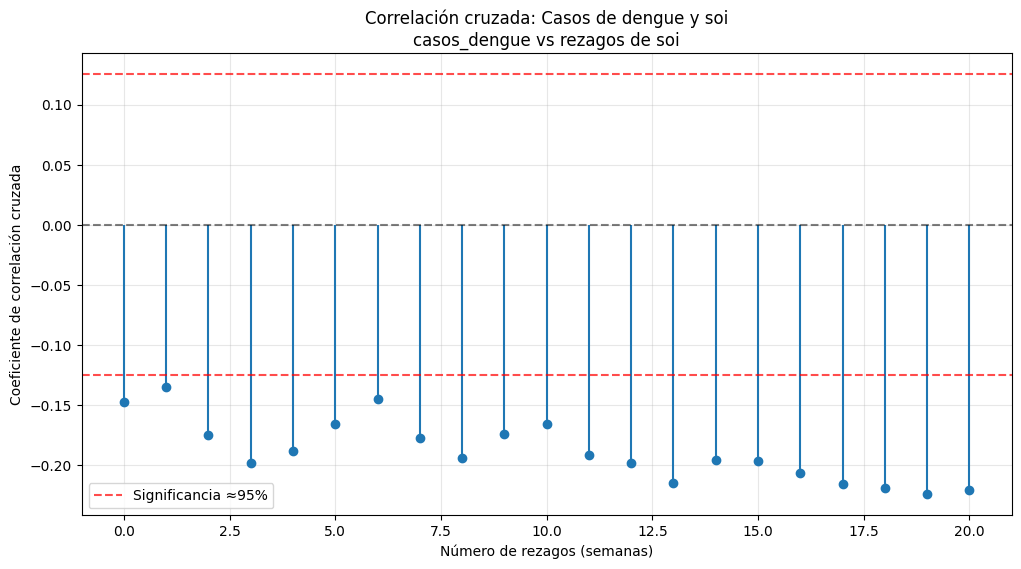


=== Rezagos más relevantes para casos_dengue vs soi ===
Lag  2: -0.1749
Lag  3: -0.1980
Lag  4: -0.1876
Lag  5: -0.1657
Lag  7: -0.1768
Lag  8: -0.1935
Lag  9: -0.1738
Lag 10: -0.1653
Lag 11: -0.1913
Lag 12: -0.1981
Lag 13: -0.2144
Lag 14: -0.1955
Lag 15: -0.1962
Lag 16: -0.2059
Lag 17: -0.2151
Lag 18: -0.2191
Lag 19: -0.2239
Lag 20: -0.2201
------------------------------------------------------------


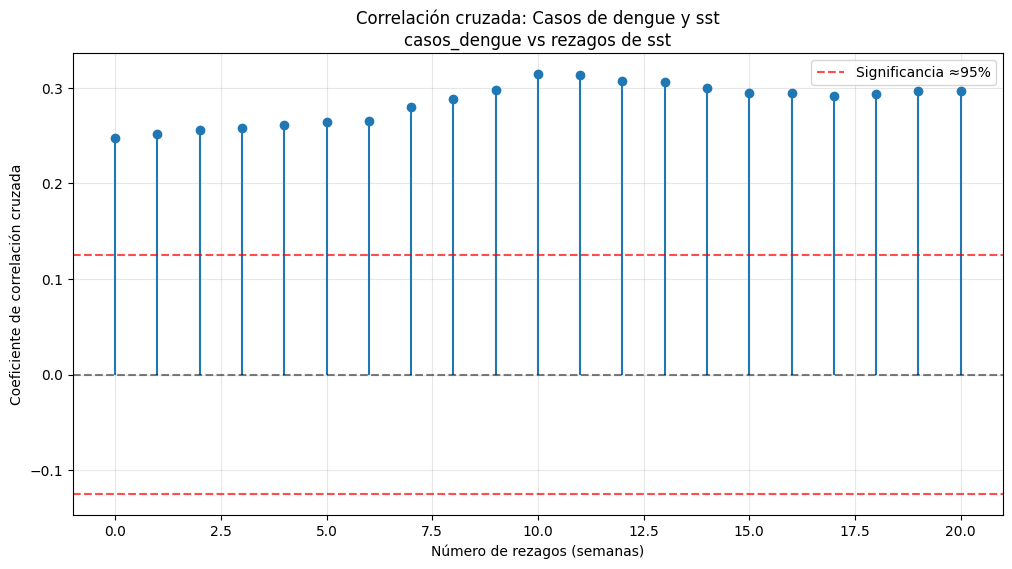


=== Rezagos más relevantes para casos_dengue vs sst ===
Lag  1: +0.2514
Lag  2: +0.2559
Lag  3: +0.2581
Lag  4: +0.2612
Lag  5: +0.2643
Lag  6: +0.2653
Lag  7: +0.2799
Lag  8: +0.2884
Lag  9: +0.2979
Lag 10: +0.3144
Lag 11: +0.3131
Lag 12: +0.3072
Lag 13: +0.3057
Lag 14: +0.3003
Lag 15: +0.2944
Lag 16: +0.2945
Lag 17: +0.2912
Lag 18: +0.2933
Lag 19: +0.2972
Lag 20: +0.2973
------------------------------------------------------------


In [14]:
# ====================== Función para calcular y graficar CCF ====================== 
def plot_cross_correlation(df, var_x, var_y, max_lags=20, title="", save_path=None):
    """
    Calcula y grafica la correlación cruzada entre dos series
    """
    x = df[var_x].values
    y = df[var_y].values
    
    # Calcular correlación cruzada
    correlation = signal.correlate(y - np.mean(y), x - np.mean(x), mode='full')
    lags = signal.correlation_lags(len(y), len(x), mode='full')
    
    # Normalizar
    correlation = correlation / (np.std(y) * np.std(x) * len(y))
    
    # Solo lags positivos (0 en adelante)
    pos_mask = lags >= 0
    lags_pos = lags[pos_mask][:max_lags+1]
    corr_pos = correlation[pos_mask][:max_lags+1]
    
    # Graficar
    plt.figure(figsize=(12, 6))
    plt.stem(lags_pos, corr_pos, basefmt=" ")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7, label='Significancia ≈95%')
    plt.axhline(y=-1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7)
    
    plt.title(f'Correlación cruzada: {title}\n{var_y} vs rezagos de {var_x}')
    plt.xlabel('Número de rezagos (semanas)')
    plt.ylabel('Coeficiente de correlación cruzada')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Guardar la imagen ANTES de show()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Mostrar rezagos relevantes
    print(f"\n=== Rezagos más relevantes para {var_y} vs {var_x} ===")
    for i in range(1, max_lags+1):
        if abs(corr_pos[i]) > 0.15:
            sign = "+" if corr_pos[i] > 0 else ""
            print(f"Lag {i:2d}: {sign}{corr_pos[i]:.4f}")
    print("-" * 60)


# ====================== 5. Calcular CCF y guardar gráficos ======================

variables_a_analizar = [
    'prec', 'dias_lluvia', 'temp', 'temp_max', 'temp_min',
    'hum_esp', 'hum_rel', 'vel_vi', 'vel_vi_max',
    'vel_vi_min', 'uv', 'soi', 'sst'
]

print("\nCalculando correlaciones cruzadas y guardando gráficos...\n")

for var in variables_a_analizar:
    filename = f"ccf_casos_dengue_{var}.png"
    save_path = f"{ubicacion_imagenes_janis}/2.{filename}"
    
    plot_cross_correlation(
        df=df_semanal_meteo_epi_rezago_prepo,  
        var_x=var,
        var_y='casos_dengue',
        max_lags=20,
        title=f"Casos de dengue y {var}",
        save_path=save_path          # ← Ahora pasamos la ruta
    )

In [ ]:
# Generar el archivo .txt con los nombres de las columnas o variables del DataFrame 
import os 
# --- CÓDIGO PARA GENERAR EL ARCHIVO .TXT ---

# Definir la ruta de la carpeta y el nombre del archivo
folder_destino = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\5_datos_preprocesados"
file_name = "atributos_dataframe.txt"
full_path = os.path.join(folder_destino, file_name)

# Asegurarse de que la carpeta de destino exista (la crea si no existe)
if not os.path.exists(folder_destino):
    os.makedirs(folder_destino)

# Obtener la lista de nombres de las columnas
atributos = datos_semanal_meteo_epi.columns.tolist()

# Guardar en el archivo .txt
with open(full_path, "w", encoding="utf-8") as f:
    for columna in atributos:
        f.write(f"{columna}\n")

print(f"Archivo guardado exitosamente en: {full_path}")

Archivo guardado exitosamente en: C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\5_datos_preprocesados\atributos_dataframe.txt


In [51]:
import pandas as pd

# Datos actualizados con recomendación
data = {
    'Variable': [
        'hum_esp_bc', 
        'hum_rel_bc', 
        'vel_vi_max_bc', 
        'temp_max_bc', 
        'vel_vi_bc', 
        'dias_lluvia_ln', 
        'prec_ln', 
        'temp_bc', 
        'sst_yj', 
        'uv_bc', 
        'soi_yj', 
        'vel_vi_min_bc'
    ],
    'Correlación más alta': [
        '+0.5946', '+0.5603', '+0.4669', '-0.4525', 
        '+0.4136', '+0.4175', '+0.3784', '-0.3988', 
        '+0.3944', '-0.2639', '-0.2138', '-0.2198'
    ],
    'Rezagos clave': [
        '1,2,3', '1,2,3', '1,2,3', '1,2', 
        '2,4', '4,5', '5,8', '1,2', 
        '9,10,11', '6,11', '13', '3'
    ],
    'Recomendación de rezagos a usar': [
        'Lags 1 al 6', 
        'Lags 1 al 6', 
        'Lags 1 al 5', 
        'Lags 1 al 4', 
        'Lags 1 al 6', 
        'Lags 1 al 8', 
        'Lags 4 al 8', 
        'Lags 1 al 4', 
        'Lags 8 al 12', 
        'Lags 5 al 12 (opcional)', 
        'Lag 10 al 15 (opcional)', 
        'No recomendado (débil)'
    ],
    'Tipo de correlación': [
        'Muy fuerte positiva', 
        'Muy fuerte positiva', 
        'Fuerte positiva', 
        'Fuerte negativa', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada negativa', 
        'Moderada positiva (retrasada)', 
        'Débil negativa', 
        'Débil negativa', 
        'Débil negativa'
    ]
}

# Crear la tabla
tabla_rezagos = pd.DataFrame(data)

# Mostrar tabla bonita en Jupyter / VS Code
styled_table = tabla_rezagos.style.set_caption("📊 Rezagos relevantes según correlación cruzada con casos_ln") \
                                 .set_properties(**{'text-align': 'left'}) \
                                 .background_gradient(subset=['Correlación más alta'], cmap='RdYlGn')

display(styled_table)

# Guardar en archivos (útil para tenerla siempre)
tabla_rezagos.to_excel(ubicacion_datos_consolidados_janis + '/rezagos_relevantes_dengue.xlsx', index=False)

print("✅ Tabla creada y guardada exitosamente como:")
print("rezagos_relevantes_dengue.xlsx")

,Variable,Correlación más alta,Rezagos clave,Recomendación de rezagos a usar,Tipo de correlación
0,hum_esp_bc,+0.5946,"1,2,3",Lags 1 al 6,Muy fuerte positiva
1,hum_rel_bc,+0.5603,"1,2,3",Lags 1 al 6,Muy fuerte positiva
2,vel_vi_max_bc,+0.4669,"1,2,3",Lags 1 al 5,Fuerte positiva
3,temp_max_bc,-0.4525,"1,2",Lags 1 al 4,Fuerte negativa
4,vel_vi_bc,+0.4136,"2,4",Lags 1 al 6,Moderada positiva
5,dias_lluvia_ln,+0.4175,"4,5",Lags 1 al 8,Moderada positiva
6,prec_ln,+0.3784,"5,8",Lags 4 al 8,Moderada positiva
7,temp_bc,-0.3988,"1,2",Lags 1 al 4,Moderada negativa
8,sst_yj,+0.3944,"9,10,11",Lags 8 al 12,Moderada positiva (retrasada)
9,uv_bc,-0.2639,"6,11",Lags 5 al 12 (opcional),Débil negativa


✅ Tabla creada y guardada exitosamente como:
rezagos_relevantes_dengue.xlsx


In [65]:
df_corr = datos_procesados.select_dtypes(include=['float64', 'int64']).drop(columns=['año'])

In [69]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_bc_lambda', 'temp_max_bc',
       'temp_max_bc_lambda', 'temp_min_bc', 'temp_min_bc_lambda', 'hum_esp_bc',
       'hum_esp_bc_lambda', 'hum_rel_bc', 'hum_rel_bc_lambda', 'vel_vi_bc',
       'vel_vi_bc_lambda', 'vel_vi_max_bc', 'vel_vi_max_bc_lambda',
       'vel_vi_min_bc', 'vel_vi_min_bc_lambda', 'uv_bc', 'uv_bc_lambda',
       'soi_yj', 'sst_yj'],
      dtype='object')

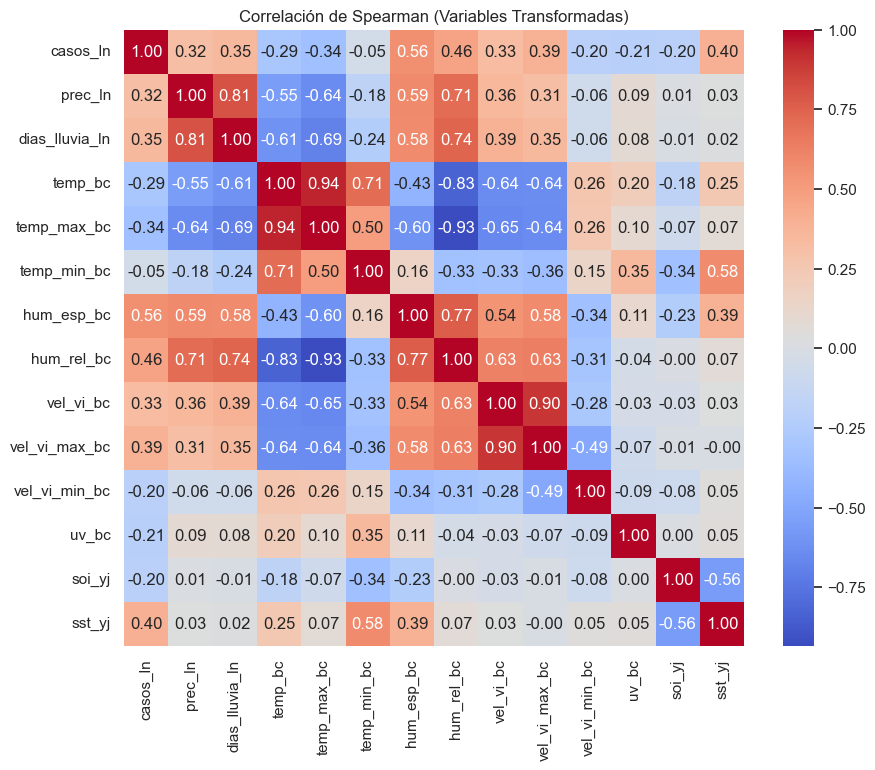


Correlación con casos de dengue (transformados):
                casos_ln
casos_ln        1.000000
hum_esp_bc      0.564113
hum_rel_bc      0.464611
sst_yj          0.397949
vel_vi_max_bc   0.391557
dias_lluvia_ln  0.348841
vel_vi_bc       0.330541
prec_ln         0.317112
temp_min_bc    -0.046010
soi_yj         -0.196389
vel_vi_min_bc  -0.196826
uv_bc          -0.213838
temp_bc        -0.287819
temp_max_bc    -0.339709


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. Seleccionar SOLO variables transformadas
# =========================

df_corr = datos_procesados[[
    'casos_ln',
    
    # Log
    'prec_ln',
    'dias_lluvia_ln',
    
    # Box-Cox
    'temp_bc',
    'temp_max_bc',
    'temp_min_bc',
    'hum_esp_bc',
    'hum_rel_bc',
    'vel_vi_bc',
    'vel_vi_max_bc',
    'vel_vi_min_bc',
    'uv_bc',
    
    # Yeo-Johnson
    'soi_yj',
    'sst_yj'
]]

# =========================
# 2. Calcular correlación de Spearman
# =========================

corr_spearman = df_corr.corr(method='spearman')

# =========================
# 3. Visualizar matriz completa
# =========================

plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlación de Spearman (Variables Transformadas)')
plt.show()

# =========================
# 4. Correlación SOLO con casos de dengue
# =========================

corr_casos = corr_spearman[['casos_ln']].sort_values(by='casos_ln', ascending=False)

print("\nCorrelación con casos de dengue (transformados):")
print(corr_casos)

## Prueba de normalidad

In [52]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = datos_procesados.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi', 'temp_bc_lambda', 'temp_max_bc_lambda', 'temp_min_bc_lambda', 'hum_esp_bc_lambda', 'hum_rel_bc_lambda', 'vel_vi_bc_lambda', 'vel_vi_max_bc_lambda', 'vel_vi_min_bc_lambda', 'uv_bc_lambda'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.917537,8.004622e-11,False
temp_max,0.883120,2.825387e-13,False
temp_min,0.980537,1.226305e-03,False
hum_esp,0.948490,5.846115e-08,False
hum_rel,0.830594,3.401543e-16,False
prec,0.890732,8.840685e-13,False
dias_lluvia,0.880142,1.833430e-13,False
vel_vi,0.977046,3.204057e-04,False
vel_vi_max,0.964436,4.612705e-06,False
vel_vi_min,0.975928,2.120517e-04,False


In [ ]:
# ====================== CREAR DATAFRAME CON REZAGOS (12 SEMANAS) ======================

# Crear una copia para no modificar el dataframe original
datos_procesados_rezagos = datos_procesados.copy()

# Variables exógenas a las que les quieres crear rezagos
exog_vars = [
    'prec_ln', 'dias_lluvia_ln',
    'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc',
    'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
    'soi_yj', 'sst_yj'
]
# Rezagos deseados: 12 semanas
lags = list(range(1, 13))        # ← Esto crea [1, 2, 3, ..., 12]

# Crear los rezagos
for var in exog_vars:
    for lag in lags:
        datos_procesados_rezagos[f'{var}_lag{lag}'] = datos_procesados_rezagos[var].shift(lag)

# Eliminar las filas con NaN generadas por los rezagos (muy recomendable)
datos_procesados_rezagos = datos_procesados_rezagos.dropna().reset_index(drop=True)

# ====================== MENSAJES FINALES ======================
print("✅ Rezagos creados correctamente (12 semanas)")
print(f"Dimensiones del dataframe con rezagos: {datos_procesados_rezagos.shape}")
print(f"Total de columnas: {len(datos_procesados_rezagos.columns)}")

# Mostrar información de los rezagos
lag_columns = [col for col in datos_procesados_rezagos.columns if '_lag' in col]

print(f"\nTotal de columnas de rezagos creadas: {len(lag_columns)}")
print("\nColumnas de rezagos creadas:")
print(lag_columns)


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()